# Data Set

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split

In [2]:

# Load the features from Final_Features.csv
df = pd.read_csv("final_features.csv")


In [3]:
df.head(10)

,RecID,Channel,Mean,Variance,Skewness,Kurtosis,RMS,IQR,Zero Crossings,Envelope,...,Weight,Hypertension,Diabetes,Placental_position,Bleeding_first_trimester,Bleeding_second_trimester,Funneling,Smoker,Premature,Early
0,1007,1,0.086840,1.364579,0.235549,0.293438,1.171375,1.404729,22387,8.043067,...,58,0,0,0,0,0,0,0,1,0
1,1007,2,-0.052190,0.894388,-0.088070,0.626220,0.947160,1.105572,22544,7.922214,...,58,0,0,0,0,0,0,0,1,0
2,1007,3,-0.034652,0.729581,-0.029736,0.885161,0.854858,1.008044,22547,8.138432,...,58,0,0,0,0,0,0,0,1,0
3,1021,1,0.001181,0.988277,0.062515,0.816469,0.994122,1.105503,22535,8.859285,...,63,0,0,1,1,0,0,0,0,1
4,1021,2,0.012205,0.748083,0.187807,2.483119,0.865004,0.825335,22505,8.692404,...,63,0,0,1,1,0,0,0,0,1
5,1021,3,-0.013369,1.263306,0.010589,0.818942,1.124048,1.165507,22443,9.087086,...,63,0,0,1,1,0,0,0,0,1
6,1022,1,-0.026248,1.148033,-0.012676,-0.128585,1.071784,1.468945,22790,8.092515,...,70,0,0,1,1,0,0,0,0,0
7,1022,2,-0.003200,0.873497,0.137160,1.007756,0.934616,1.076626,22614,8.585365,...,70,0,0,1,1,0,0,0,0,0
8,1022,3,0.029461,0.976888,0.048477,-0.057641,0.988816,1.311171,22818,7.605033,...,70,0,0,1,1,0,0,0,0,0
9,1027,1,-0.023835,1.353571,-0.046137,-0.440292,1.163675,1.674650,23085,7.334200,...,100,0,0,0,0,0,0,0,0,0


In [4]:
len(df.columns)


40

In [5]:
print(df.columns)

Index(['RecID', 'Channel', 'Mean', 'Variance', 'Skewness', 'Kurtosis', 'RMS',
       'IQR', 'Zero Crossings', 'Envelope', 'PSD Band 0.3–0.6 Hz',
       'PSD Band 0.6–1.0 Hz', 'Mean Frequency', 'Spectral Entropy',
       'Wavelet Energy Level 1', 'Wavelet Energy Level 3', 'Wavelet Entropy',
       'Instantaneous Amplitude Std', 'Instantaneous Frequency Mean',
       'Instantaneous Frequency Std', 'Sample Entropy', 'Recurrence Rate',
       'Determinism', 'Laminarity', 'L_max', 'Gestation', 'RecTime', 'Age',
       'Parity', 'Abortions', 'Weight', 'Hypertension', 'Diabetes',
       'Placental_position', 'Bleeding_first_trimester',
       'Bleeding_second_trimester', 'Funneling', 'Smoker', 'Premature',
       'Early'],
      dtype='object')


In [6]:

# Separate features and target
X = df.drop(columns=["Premature",'RecID'])  # Features (exclude target column 'Premature')
y = df["Premature"]          

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
# Initialize ADASYN
adasyn = ADASYN(sampling_strategy='minority', random_state=42, n_neighbors=5)

# Apply ADASYN to the training data
X_train_balanced, y_train_balanced = adasyn.fit_resample(X_train, y_train)

# Check the class distribution after applying ADASYN
from collections import Counter
print("Class distribution after ADASYN:", Counter(y_train_balanced))


Class distribution after ADASYN: Counter({1: 638, 0: 629})


In [8]:
pip install torch torchvision torch-geometric


^C
Note: you may need to restart the kernel to use updated packages.


c:\Users\knand\miniconda3\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\knand\miniconda3\Lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\knand\miniconda3\Lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\Users\knand\miniconda3\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling i

Epoch 1, Loss: 0.7431803345680237
Epoch 2, Loss: 0.646488606929779
Epoch 3, Loss: 0.5688737034797668
Epoch 4, Loss: 0.5074776411056519
Epoch 5, Loss: 0.4586285352706909
Epoch 6, Loss: 0.419646292924881
Epoch 7, Loss: 0.3885660469532013
Epoch 8, Loss: 0.36362767219543457
Epoch 9, Loss: 0.3434619903564453
Epoch 10, Loss: 0.32717159390449524
Epoch 11, Loss: 0.31377503275871277
Epoch 12, Loss: 0.3022865653038025
Epoch 13, Loss: 0.29197806119918823
Epoch 14, Loss: 0.2820824384689331
Epoch 15, Loss: 0.27181538939476013
Epoch 16, Loss: 0.26100778579711914
Epoch 17, Loss: 0.2498132735490799
Epoch 18, Loss: 0.23833037912845612
Epoch 19, Loss: 0.22681061923503876
Epoch 20, Loss: 0.21567192673683167
Epoch 21, Loss: 0.20527483522891998
Epoch 22, Loss: 0.19551122188568115
Epoch 23, Loss: 0.18638551235198975
Epoch 24, Loss: 0.1778920739889145
Epoch 25, Loss: 0.16998842358589172
Epoch 26, Loss: 0.16251888871192932
Epoch 27, Loss: 0.15530595183372498
Epoch 28, Loss: 0.14832958579063416
Epoch 29, Loss:

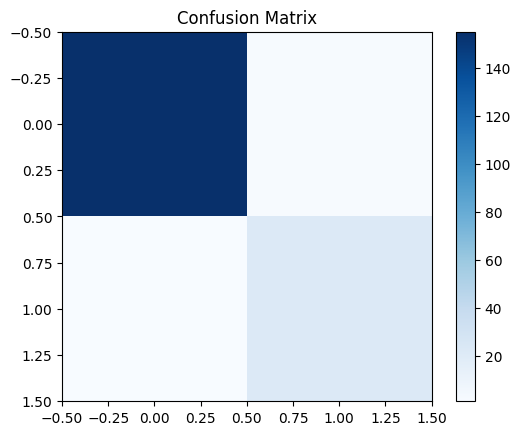

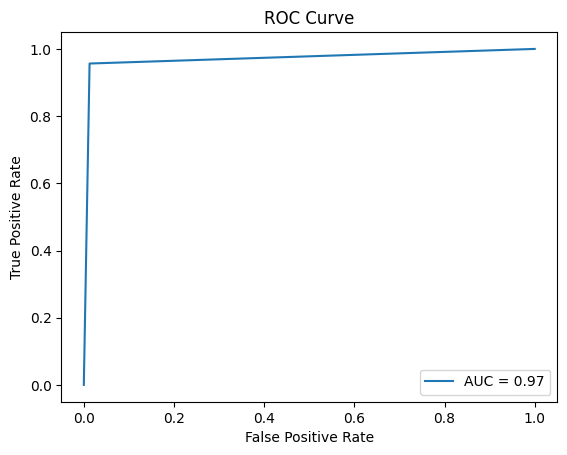

In [9]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Load data
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("final_features.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Build graph
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(X_train)
edge_index = torch.tensor(np.array(np.where(similarity_matrix > 0.8)), dtype=torch.long)  # Define edges

# Prepare PyTorch Geometric Data
node_features = torch.tensor(X_train, dtype=torch.float)
labels = torch.tensor(y_train.values, dtype=torch.long)
data = Data(x=node_features, edge_index=edge_index, y=labels)

# Define GNN Model
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Initialize model
model = GCN(in_channels=X_train.shape[1], hidden_channels=16, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Rebuild graph for testing
similarity_matrix_test = cosine_similarity(X_test)
test_edge_index = torch.tensor(np.array(np.where(similarity_matrix_test > 0.8)), dtype=torch.long)  # Define edges for test set

# Prepare PyTorch Geometric Test Data
test_node_features = torch.tensor(X_test, dtype=torch.float)
test_data = Data(x=test_node_features, edge_index=test_edge_index)

# Test the model
model.eval()
with torch.no_grad():
    test_output = model(test_data.x, test_data.edge_index)
    predictions = test_output.argmax(dim=1)

# Classification Report
print(classification_report(y_test, predictions))


# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


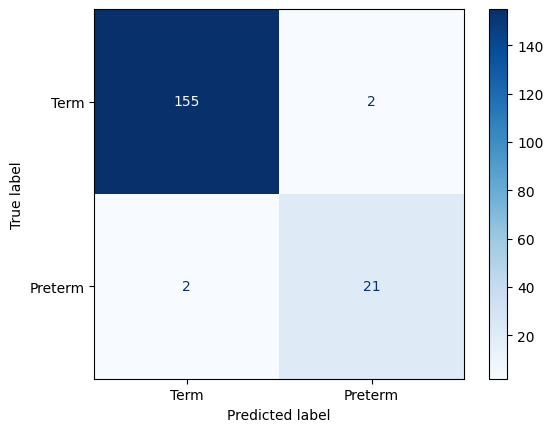

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=["Term", "Preterm"], cmap="Blues")


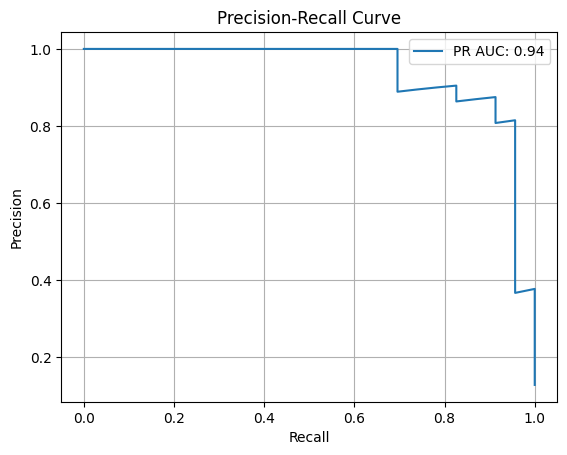

In [27]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, test_output[:, 1])  # Use probabilities for class 1
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()


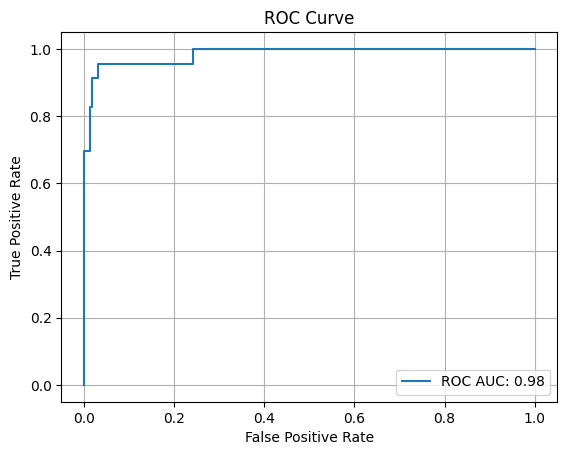

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_output[:, 1])  # Use probabilities for class 1
roc_auc = roc_auc_score(y_test, test_output[:, 1])

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC: {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [29]:
torch.save(model.state_dict(), "gnn_preterm_model.pth")


In [30]:
model.load_state_dict(torch.load("gnn_preterm_model.pth"))
model.eval()


C:\Users\knand\AppData\Local\Temp\ipykernel_22728\947772057.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("gnn_preterm_model.pth"))


GCN(
  (conv1): GCNConv(38, 16)
  (conv2): GCNConv(16, 2)
)

In [38]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from sklearn.metrics.pairwise import cosine_similarity
from torch.nn.functional import cross_entropy

# Load and preprocess data
df = pd.read_csv("final_features.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Oversampling with ADASYN
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_scaled, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

# Build graph
similarity_matrix = cosine_similarity(X_train)
edge_index = torch.tensor(np.array(np.where(similarity_matrix > 0.85)), dtype=torch.long)  # Adjusted threshold

# Prepare PyTorch Geometric Data
node_features = torch.tensor(X_train, dtype=torch.float)
labels = torch.tensor(y_train.values, dtype=torch.long)
data = Data(x=node_features, edge_index=edge_index, y=labels)

# Define class weights
class_weights = torch.tensor([(len(y_train) - y_train.sum()) / len(y_train), y_train.sum() / len(y_train)], dtype=torch.float)

# Define GraphSAGE Model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(dropout)
        self.bn = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.bn(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

# Initialize model
model = GraphSAGEModel(in_channels=X_train.shape[1], hidden_channels=32, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# Train the model
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Rebuild graph for testing
similarity_matrix_test = cosine_similarity(X_test)
test_edge_index = torch.tensor(np.array(np.where(similarity_matrix_test > 0.85)), dtype=torch.long)  # Adjusted threshold

# Prepare PyTorch Geometric Test Data
test_node_features = torch.tensor(X_test, dtype=torch.float)
test_labels = torch.tensor(y_test.values, dtype=torch.long)
test_data = Data(x=test_node_features, edge_index=test_edge_index, y=test_labels)

# Test the model
model.eval()
with torch.no_grad():
    test_output = model(test_data.x, test_data.edge_index)
    predictions = test_output.argmax(dim=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))



Epoch 1, Loss: 0.7490970492362976
Epoch 2, Loss: 0.6008502244949341
Epoch 3, Loss: 0.48683962225914
Epoch 4, Loss: 0.39438846707344055
Epoch 5, Loss: 0.3073713481426239
Epoch 6, Loss: 0.22787655889987946
Epoch 7, Loss: 0.15756402909755707
Epoch 8, Loss: 0.10662250965833664
Epoch 9, Loss: 0.09074960649013519
Epoch 10, Loss: 0.07017882913351059
Epoch 11, Loss: 0.05981382355093956
Epoch 12, Loss: 0.044921133667230606
Epoch 13, Loss: 0.03496196120977402
Epoch 14, Loss: 0.03511182963848114
Epoch 15, Loss: 0.030309008434414864
Epoch 16, Loss: 0.02342849411070347
Epoch 17, Loss: 0.02351963520050049
Epoch 18, Loss: 0.024059230461716652
Epoch 19, Loss: 0.026883115991950035
Epoch 20, Loss: 0.02607746049761772
Epoch 21, Loss: 0.01747020334005356
Epoch 22, Loss: 0.017144573852419853
Epoch 23, Loss: 0.006509413942694664
Epoch 24, Loss: 0.025866445153951645
Epoch 25, Loss: 0.008589500561356544
Epoch 26, Loss: 0.004428854212164879
Epoch 27, Loss: 0.019064724445343018
Epoch 28, Loss: 0.019310766831040

In [39]:
torch.save(model.state_dict(), "gnn_preterm_model2.pth")


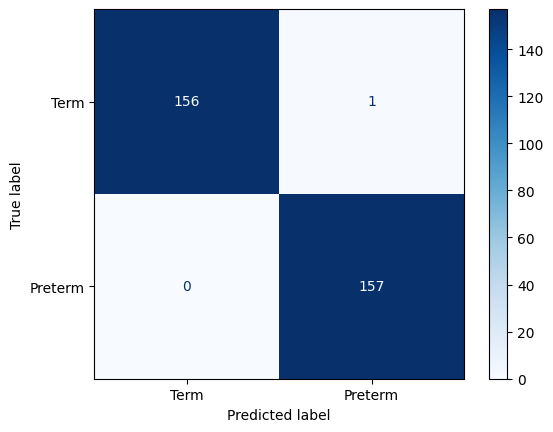

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=["Term", "Preterm"], cmap="Blues")


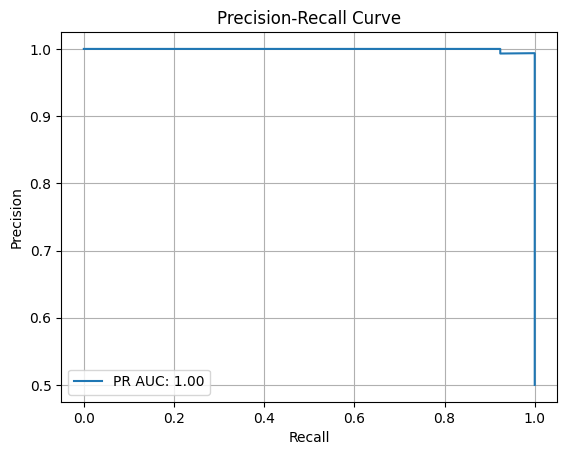

In [41]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, test_output[:, 1])  # Use probabilities for class 1
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()


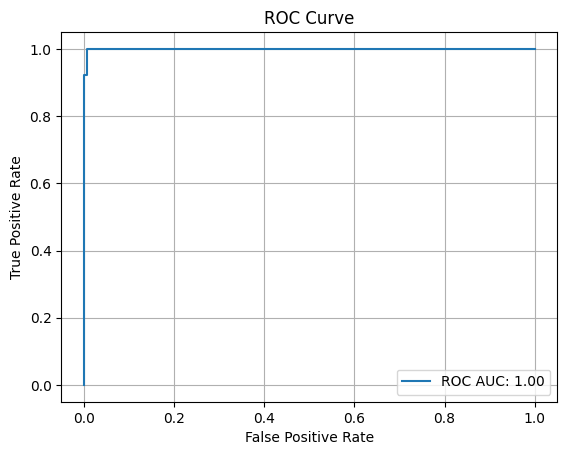

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_output[:, 1])  # Use probabilities for class 1
roc_auc = roc_auc_score(y_test, test_output[:, 1])

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC: {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [3]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from sklearn.metrics.pairwise import cosine_similarity

# Load and preprocess data
df = pd.read_csv("final_features.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Oversampling with ADASYN
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_scaled, y)

# Define GraphSAGE Model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(dropout)
        self.bn = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.bn(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

# Cross-validation setup
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    print(f"Fold {fold+1}")

    # Train-validation split
    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    # Build train graph
    similarity_matrix_train = cosine_similarity(X_train)
    train_edge_index = torch.tensor(np.array(np.where(similarity_matrix_train > 0.85)), dtype=torch.long)
    node_features_train = torch.tensor(X_train, dtype=torch.float)
    labels_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)  # Fixed here
    train_data = Data(x=node_features_train, edge_index=train_edge_index, y=labels_train)

    # Build validation graph
    similarity_matrix_val = cosine_similarity(X_val)
    val_edge_index = torch.tensor(np.array(np.where(similarity_matrix_val > 0.85)), dtype=torch.long)
    node_features_val = torch.tensor(X_val, dtype=torch.float)
    labels_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)  # Fixed here
    val_data = Data(x=node_features_val, edge_index=val_edge_index, y=labels_val)

    # Define class weights
    class_weights = torch.tensor([(len(y_train) - y_train.sum()) / len(y_train), y_train.sum() / len(y_train)], dtype=torch.float)

    # Initialize model
    model = GraphSAGEModel(in_channels=X_train.shape[1], hidden_channels=32, out_channels=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    # Train the model
    model.train()
    for epoch in range(50):  # Reduced epochs for cross-validation
        optimizer.zero_grad()
        out = model(train_data.x, train_data.edge_index)
        loss = criterion(out, train_data.y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item()}")

    # Validate the model
    model.eval()
    with torch.no_grad():
        val_output = model(val_data.x, val_data.edge_index)
        val_predictions = val_output.argmax(dim=1)

    # Classification report
    fold_report = classification_report(y_val, val_predictions, output_dict=True)
    fold_results.append(fold_report)
    print(f"Fold {fold+1} Classification Report:")
    print(classification_report(y_val, val_predictions))

# Aggregate results
mean_results = {
    "precision": np.mean([fold_results[i]["weighted avg"]["precision"] for i in range(10)]),
    "recall": np.mean([fold_results[i]["weighted avg"]["recall"] for i in range(10)]),
    "f1-score": np.mean([fold_results[i]["weighted avg"]["f1-score"] for i in range(10)]),
    "support": sum([fold_results[i]["weighted avg"]["support"] for i in range(10)])
}
print("\nMean Results Across 10 Folds:")
print(mean_results)


Fold 1
Epoch 10, Loss: 0.07239052653312683
Epoch 20, Loss: 0.014904112555086613
Epoch 30, Loss: 0.004377042409032583
Epoch 40, Loss: 0.009727150201797485
Epoch 50, Loss: 0.006149058695882559
Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        79

    accuracy                           1.00       157
   macro avg       1.00      1.00      1.00       157
weighted avg       1.00      1.00      1.00       157

Fold 2
Epoch 10, Loss: 0.05686834827065468
Epoch 20, Loss: 0.017828617244958878
Epoch 30, Loss: 0.008254007436335087
Epoch 40, Loss: 0.004500458482652903
Epoch 50, Loss: 0.004500890150666237
Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        78
           1       0.99      1.00      0.99        79

    accuracy                           0.99       157
   macro avg 

Fold 1
Epoch 10, Loss: 0.06755867600440979, Train Acc: 0.9773, Val Acc: 0.9745
Epoch 20, Loss: 0.023669101297855377, Train Acc: 0.9957, Val Acc: 0.9809
Epoch 30, Loss: 0.010944685898721218, Train Acc: 0.9972, Val Acc: 0.9936
Epoch 40, Loss: 0.007121101021766663, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 50, Loss: 0.004192540422081947, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 60, Loss: 0.002543396083638072, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 70, Loss: 0.00229780119843781, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 80, Loss: 0.005897951312363148, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 90, Loss: 0.0027095044497400522, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 100, Loss: 0.0045226565562188625, Train Acc: 0.9986, Val Acc: 1.0000


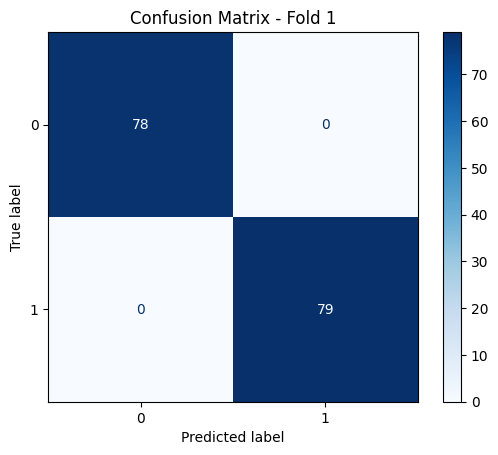

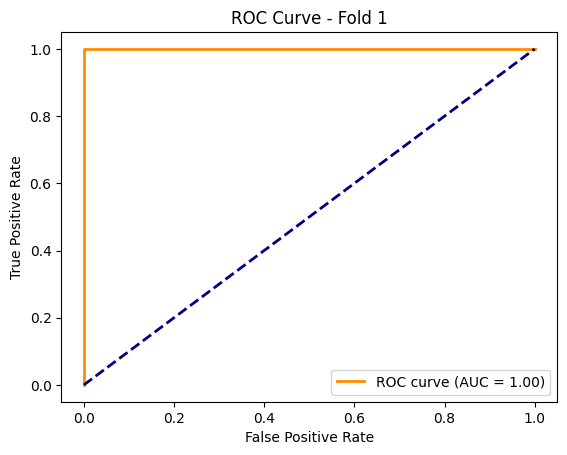

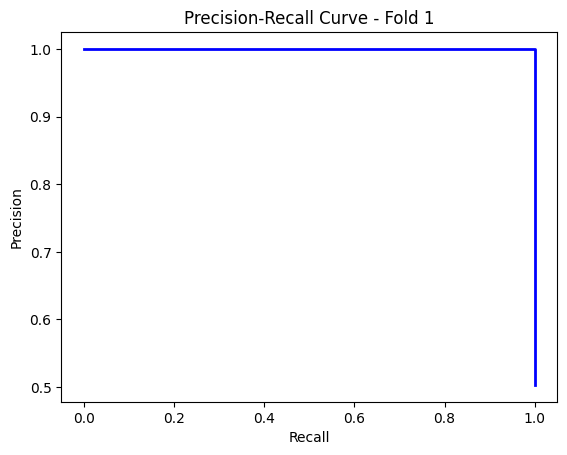

Fold 2
Epoch 10, Loss: 0.05328693613409996, Train Acc: 0.9865, Val Acc: 0.9809
Epoch 20, Loss: 0.02019394375383854, Train Acc: 0.9950, Val Acc: 0.9936
Epoch 30, Loss: 0.01093252468854189, Train Acc: 0.9957, Val Acc: 1.0000
Epoch 40, Loss: 0.004331883974373341, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 50, Loss: 0.004927922040224075, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 60, Loss: 0.004306740593165159, Train Acc: 0.9979, Val Acc: 0.9936
Epoch 70, Loss: 0.003942782990634441, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 80, Loss: 0.0060228006914258, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 90, Loss: 0.0011320427292957902, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 100, Loss: 0.003929628524929285, Train Acc: 0.9993, Val Acc: 1.0000


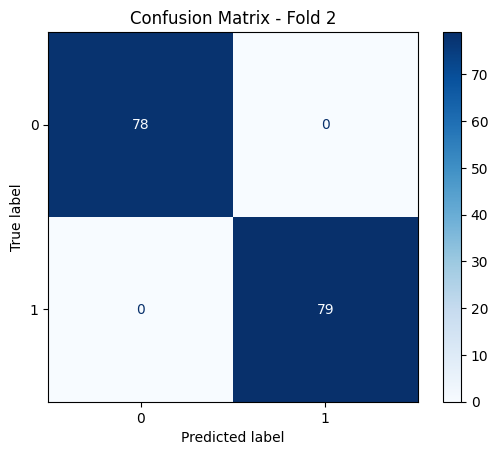

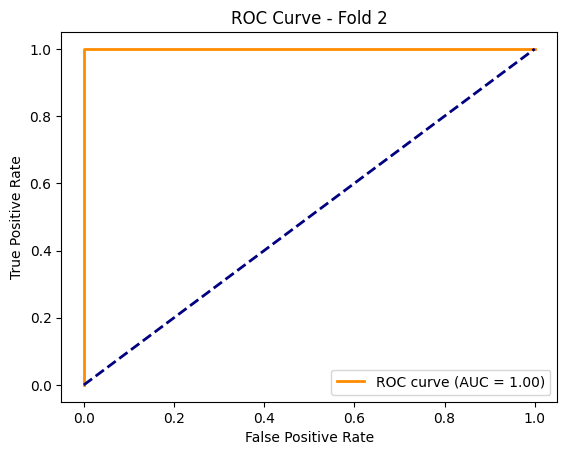

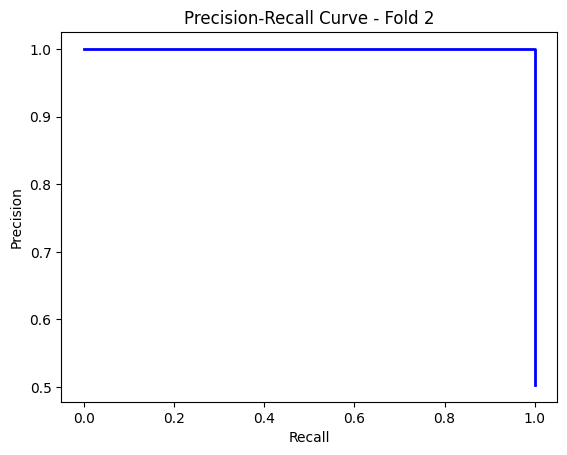

Fold 3
Epoch 10, Loss: 0.04724022001028061, Train Acc: 0.9865, Val Acc: 0.9745
Epoch 20, Loss: 0.012248666025698185, Train Acc: 0.9965, Val Acc: 1.0000
Epoch 30, Loss: 0.002157720271497965, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 40, Loss: 0.007470263168215752, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 50, Loss: 0.0036290634889155626, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 60, Loss: 0.002821526024490595, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 70, Loss: 0.004795091226696968, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 80, Loss: 0.004477583337575197, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 90, Loss: 0.0023428609129041433, Train Acc: 1.0000, Val Acc: 0.9936
Epoch 100, Loss: 0.002551035489886999, Train Acc: 0.9986, Val Acc: 1.0000


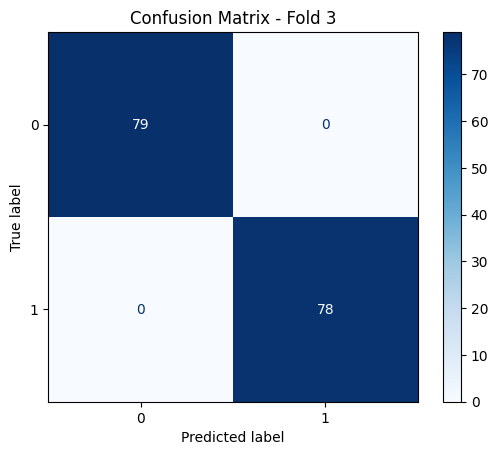

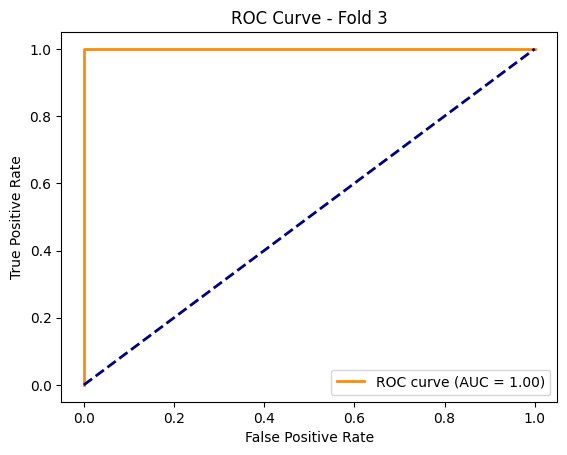

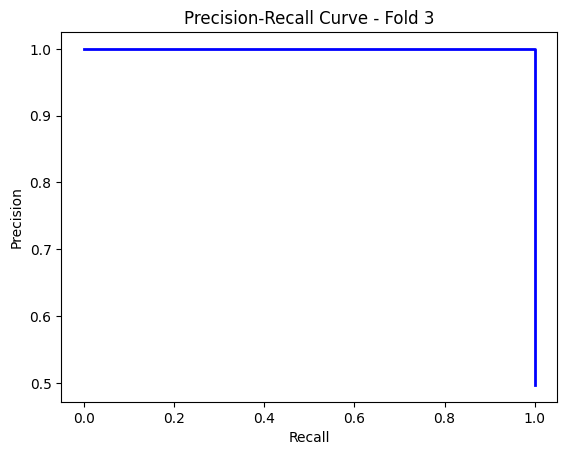

Fold 4
Epoch 10, Loss: 0.050888027995824814, Train Acc: 0.9830, Val Acc: 0.9873
Epoch 20, Loss: 0.01916850171983242, Train Acc: 0.9950, Val Acc: 1.0000
Epoch 30, Loss: 0.011016150005161762, Train Acc: 0.9972, Val Acc: 1.0000
Epoch 40, Loss: 0.010674738325178623, Train Acc: 0.9957, Val Acc: 1.0000
Epoch 50, Loss: 0.004740885924547911, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 60, Loss: 0.00251922570168972, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 70, Loss: 0.005975697189569473, Train Acc: 0.9972, Val Acc: 0.9936
Epoch 80, Loss: 0.0014224450569599867, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 90, Loss: 0.0012888782657682896, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 100, Loss: 0.0012466106563806534, Train Acc: 1.0000, Val Acc: 1.0000


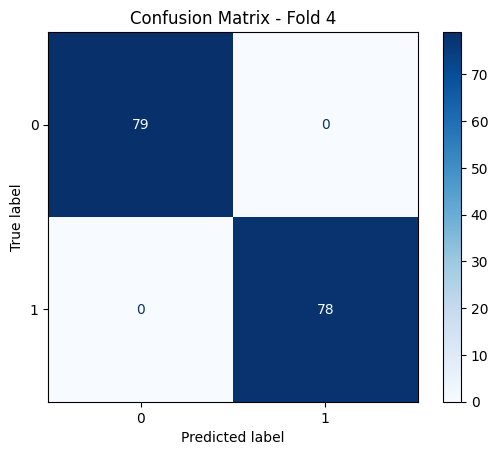

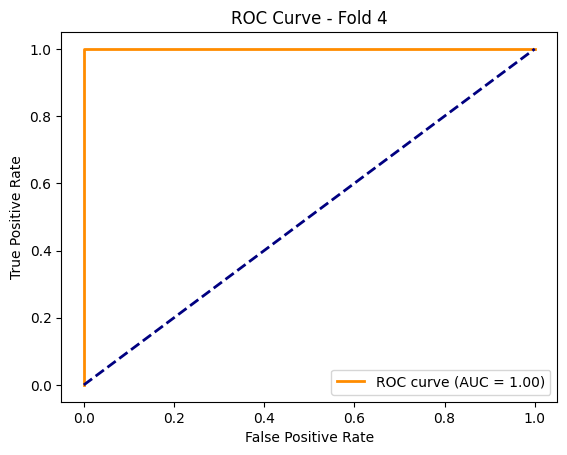

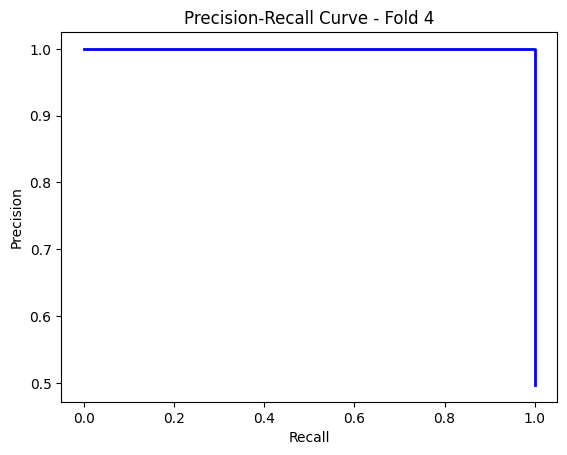

Fold 5
Epoch 10, Loss: 0.08098301291465759, Train Acc: 0.9731, Val Acc: 0.9873
Epoch 20, Loss: 0.01921277679502964, Train Acc: 0.9943, Val Acc: 0.9936
Epoch 30, Loss: 0.00834616832435131, Train Acc: 0.9979, Val Acc: 0.9936
Epoch 40, Loss: 0.01246205996721983, Train Acc: 0.9965, Val Acc: 0.9936
Epoch 50, Loss: 0.0028113110456615686, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 60, Loss: 0.00441883597522974, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 70, Loss: 0.003966992255300283, Train Acc: 0.9986, Val Acc: 0.9936
Epoch 80, Loss: 0.0018185068620368838, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 90, Loss: 0.002280253218486905, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 100, Loss: 0.002383694052696228, Train Acc: 0.9993, Val Acc: 0.9936


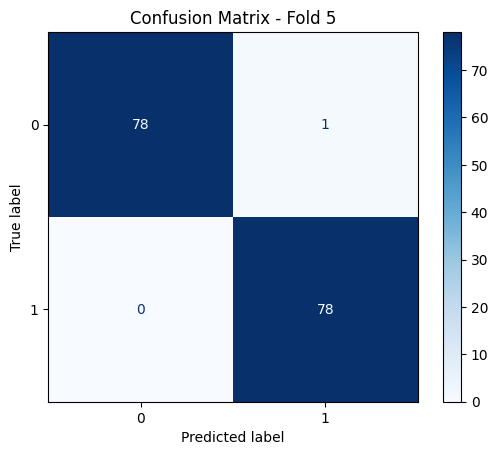

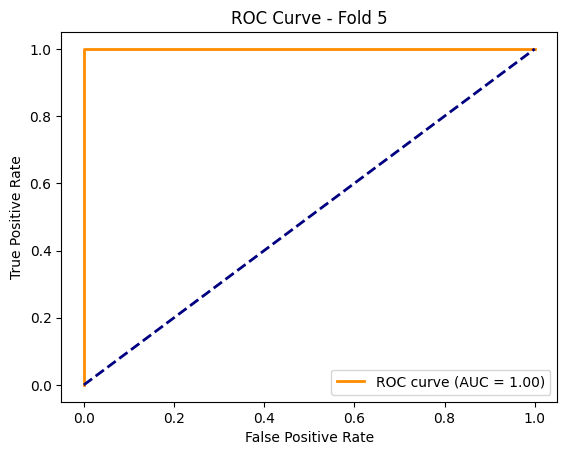

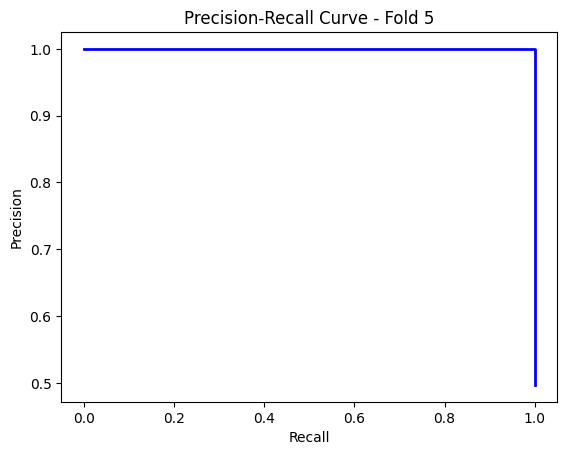

Fold 6
Epoch 10, Loss: 0.058266039937734604, Train Acc: 0.9802, Val Acc: 0.9809
Epoch 20, Loss: 0.01950940303504467, Train Acc: 0.9950, Val Acc: 0.9873
Epoch 30, Loss: 0.009140482172369957, Train Acc: 0.9979, Val Acc: 0.9936
Epoch 40, Loss: 0.0039200070314109325, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 50, Loss: 0.002178782597184181, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 60, Loss: 0.0016112420707941055, Train Acc: 1.0000, Val Acc: 0.9936
Epoch 70, Loss: 0.00436754385009408, Train Acc: 0.9986, Val Acc: 0.9936
Epoch 80, Loss: 0.0023541892878711224, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 90, Loss: 0.0019279669504612684, Train Acc: 0.9993, Val Acc: 0.9936
Epoch 100, Loss: 0.0013656883966177702, Train Acc: 1.0000, Val Acc: 0.9936


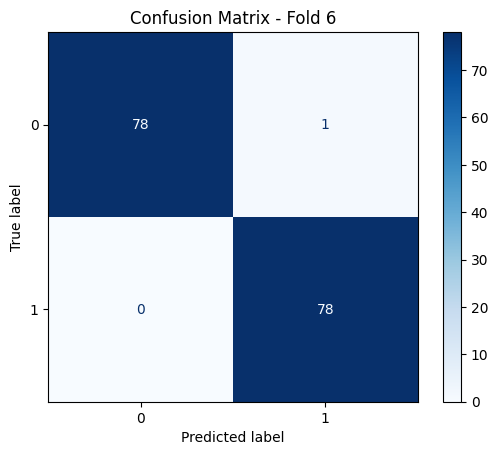

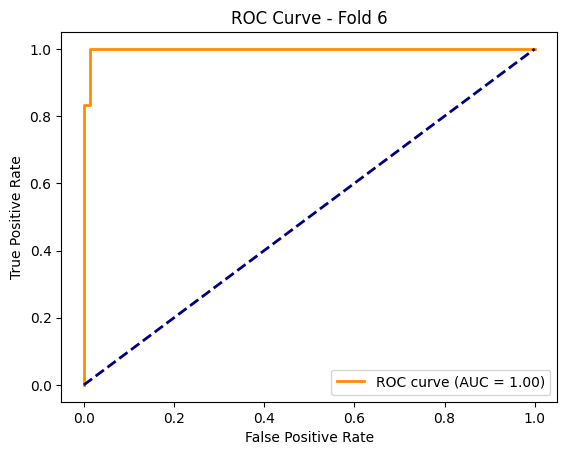

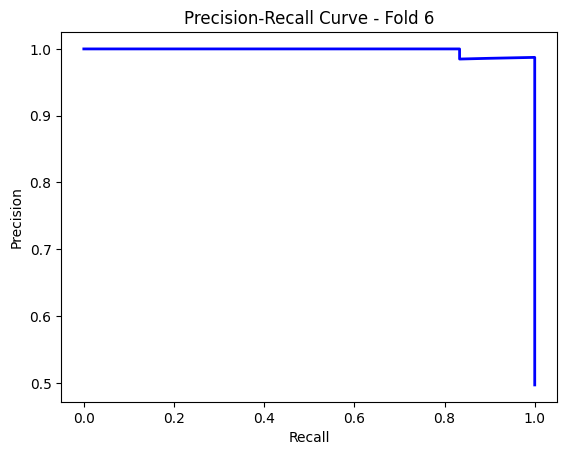

Fold 7
Epoch 10, Loss: 0.08440414071083069, Train Acc: 0.9738, Val Acc: 1.0000
Epoch 20, Loss: 0.02383020706474781, Train Acc: 0.9936, Val Acc: 0.9936
Epoch 30, Loss: 0.011878807097673416, Train Acc: 0.9957, Val Acc: 1.0000
Epoch 40, Loss: 0.009961124509572983, Train Acc: 0.9965, Val Acc: 1.0000
Epoch 50, Loss: 0.0070473067462444305, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 60, Loss: 0.0029435567557811737, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 70, Loss: 0.0025622297544032335, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 80, Loss: 0.002151631051674485, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 90, Loss: 0.001411187811754644, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 100, Loss: 0.0012291601160541177, Train Acc: 1.0000, Val Acc: 1.0000


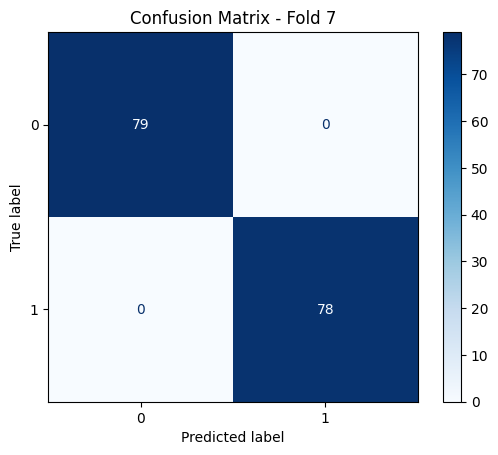

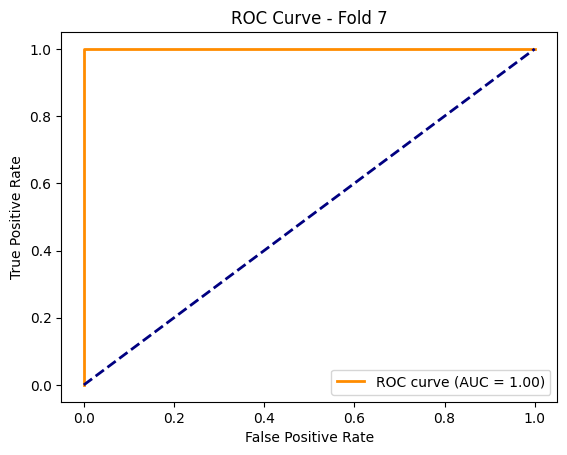

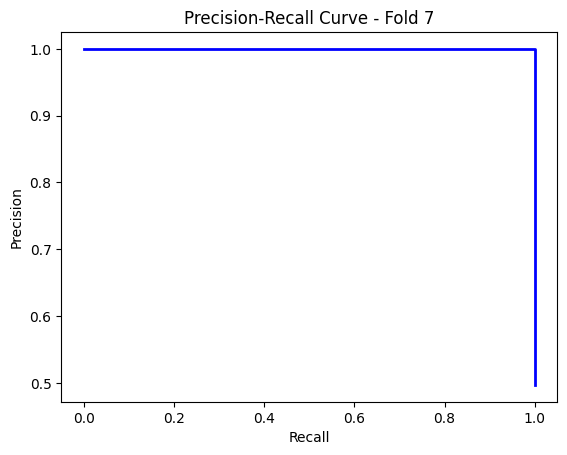

Fold 8
Epoch 10, Loss: 0.1236162930727005, Train Acc: 0.9582, Val Acc: 0.9745
Epoch 20, Loss: 0.021228425204753876, Train Acc: 0.9922, Val Acc: 0.9936
Epoch 30, Loss: 0.014403481036424637, Train Acc: 0.9972, Val Acc: 0.9936
Epoch 40, Loss: 0.005204277578741312, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 50, Loss: 0.0047639887779951096, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 60, Loss: 0.0037934689316898584, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 70, Loss: 0.0025720426347106695, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 80, Loss: 0.002865774091333151, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 90, Loss: 0.0018568435916677117, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 100, Loss: 0.0017112563364207745, Train Acc: 0.9993, Val Acc: 1.0000


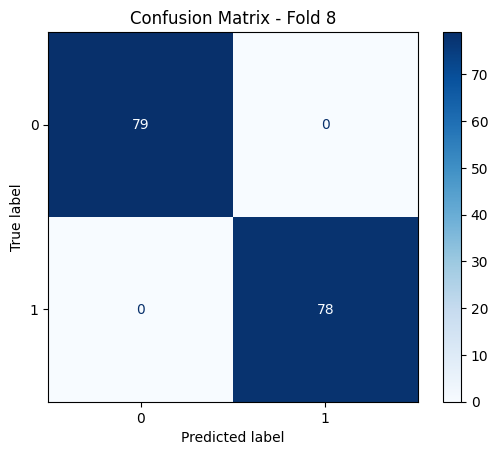

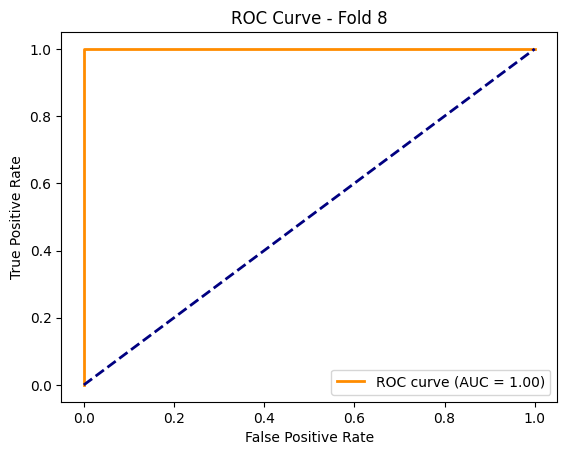

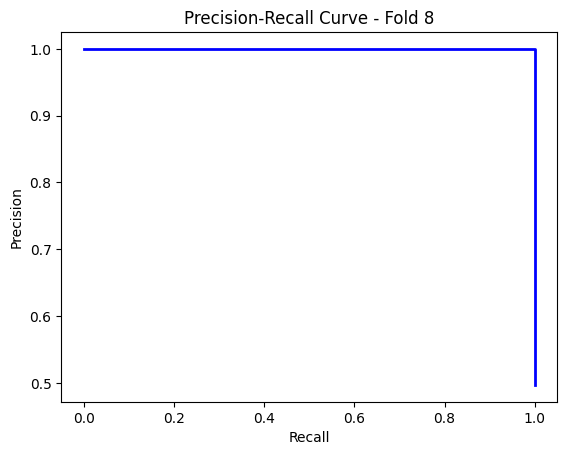

Fold 9
Epoch 10, Loss: 0.08539356291294098, Train Acc: 0.9731, Val Acc: 0.9936
Epoch 20, Loss: 0.028616156429052353, Train Acc: 0.9908, Val Acc: 0.9936
Epoch 30, Loss: 0.01772676780819893, Train Acc: 0.9936, Val Acc: 1.0000
Epoch 40, Loss: 0.009210851043462753, Train Acc: 0.9965, Val Acc: 0.9936
Epoch 50, Loss: 0.008169329725205898, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 60, Loss: 0.0017507366137579083, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 70, Loss: 0.004974924959242344, Train Acc: 0.9986, Val Acc: 0.9936
Epoch 80, Loss: 0.001637143432162702, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 90, Loss: 0.0064967237412929535, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 100, Loss: 0.0031016741413623095, Train Acc: 0.9993, Val Acc: 1.0000


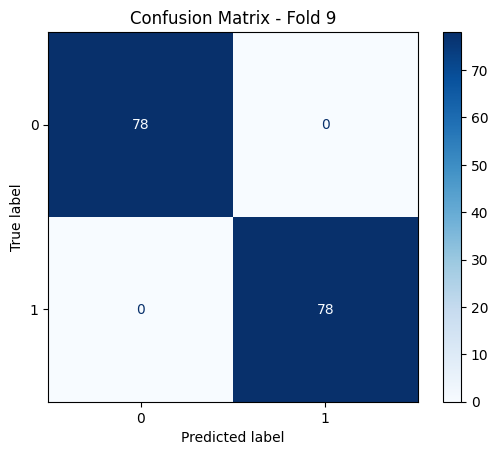

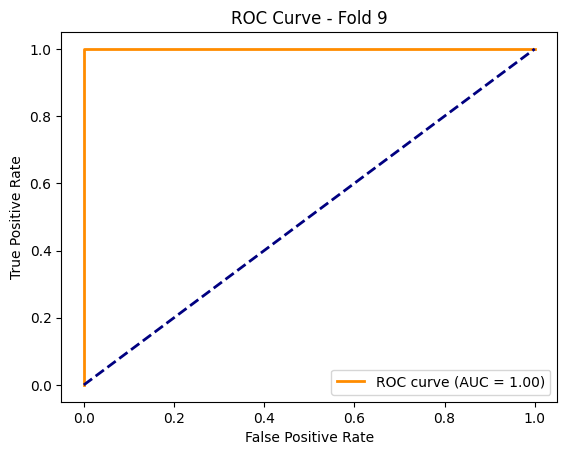

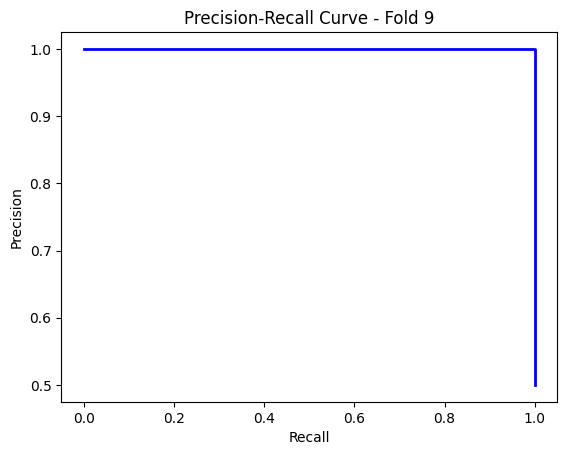

Fold 10
Epoch 10, Loss: 0.07437369227409363, Train Acc: 0.9766, Val Acc: 0.9936
Epoch 20, Loss: 0.018675150349736214, Train Acc: 0.9965, Val Acc: 1.0000
Epoch 30, Loss: 0.006024744361639023, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 40, Loss: 0.005321981851011515, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 50, Loss: 0.004169186111539602, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 60, Loss: 0.002317543374374509, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 70, Loss: 0.004507069941610098, Train Acc: 0.9986, Val Acc: 1.0000
Epoch 80, Loss: 0.005160837434232235, Train Acc: 0.9979, Val Acc: 1.0000
Epoch 90, Loss: 0.0017570918425917625, Train Acc: 0.9993, Val Acc: 1.0000
Epoch 100, Loss: 0.0017197956331074238, Train Acc: 1.0000, Val Acc: 1.0000


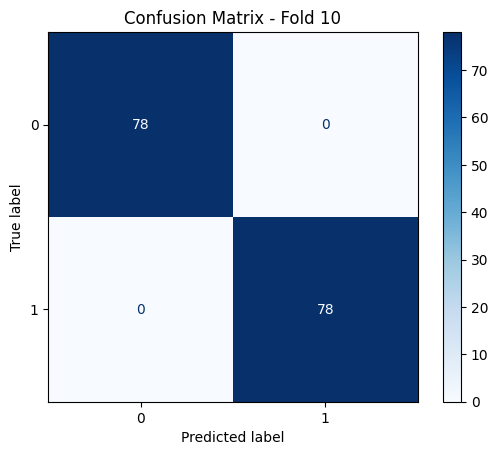

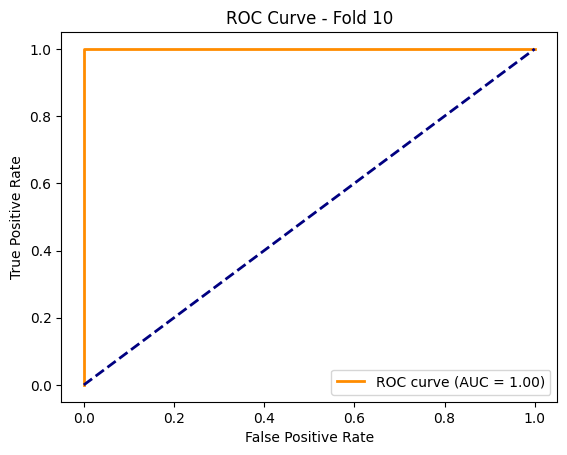

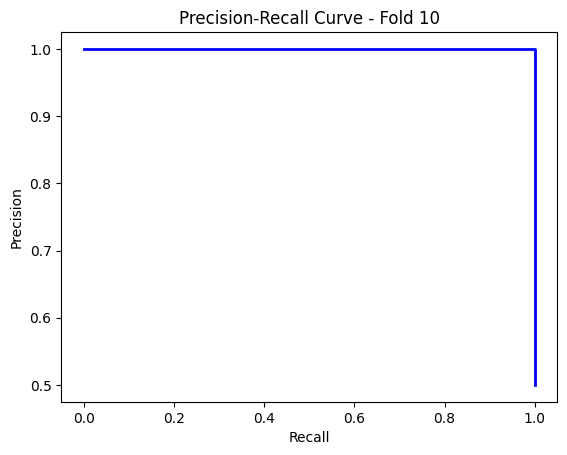

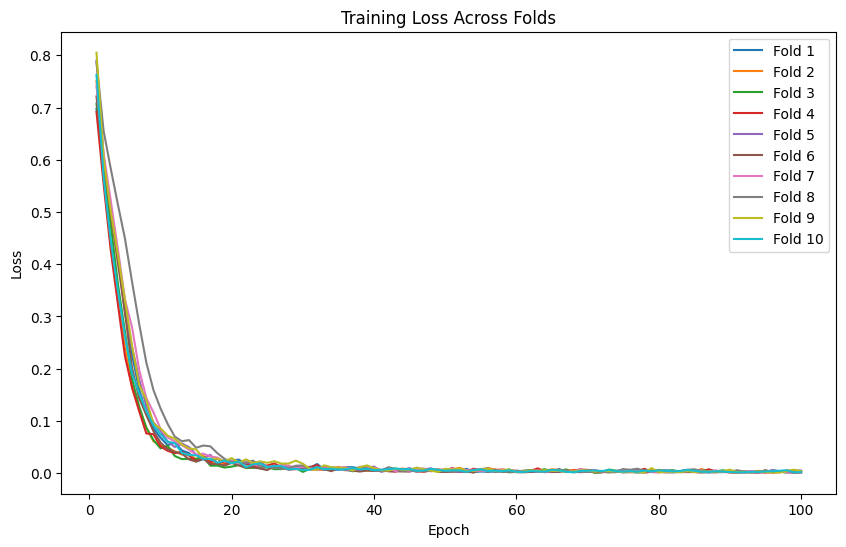

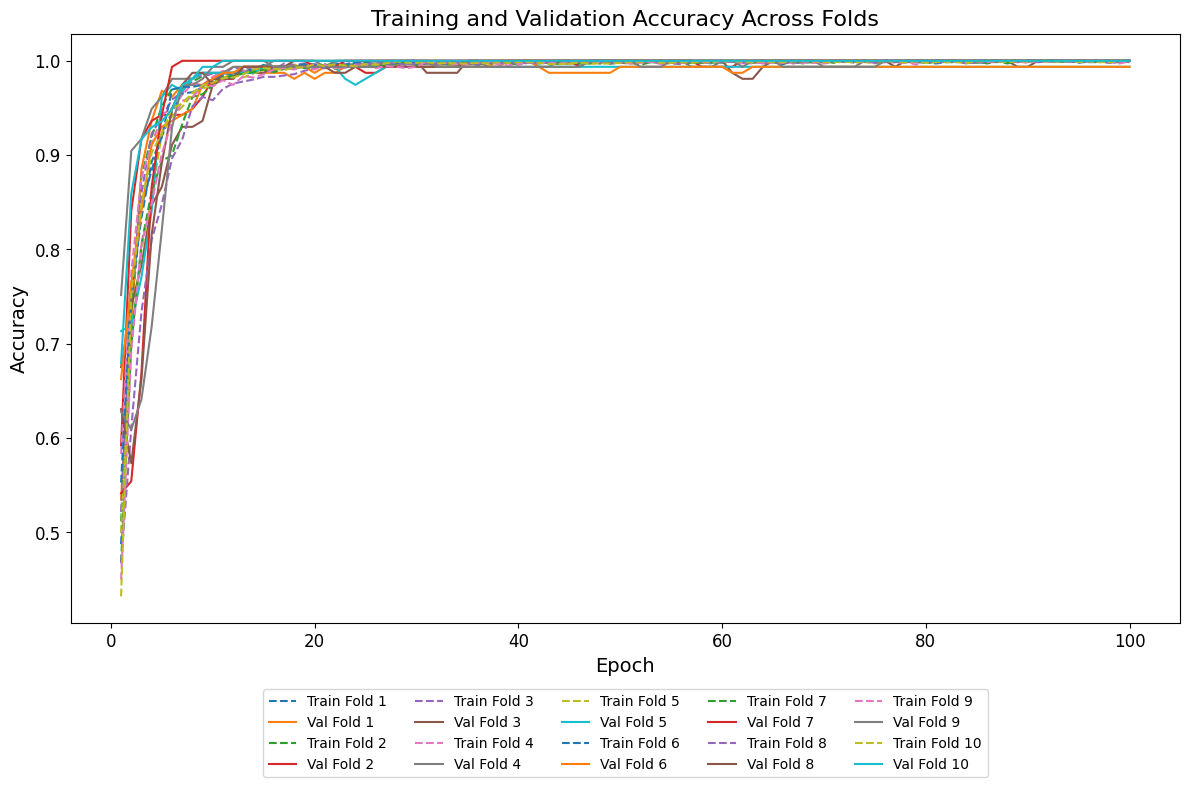

In [27]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from sklearn.metrics.pairwise import cosine_similarity

# Load and preprocess data
df = pd.read_csv("final_features.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Oversampling with ADASYN
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_scaled, y)

# Define GraphSAGE Model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(dropout)
        self.bn = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.bn(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Track losses and accuracies for plotting
losses = []
train_accuracies = []
val_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    print(f"Fold {fold+1}")

    # Train-validation split
    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    # Build train graph
    similarity_matrix_train = cosine_similarity(X_train)
    train_edge_index = torch.tensor(np.array(np.where(similarity_matrix_train > 0.85)), dtype=torch.long)
    node_features_train = torch.tensor(X_train, dtype=torch.float)
    labels_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
    train_data = Data(x=node_features_train, edge_index=train_edge_index, y=labels_train)

    # Build validation graph
    similarity_matrix_val = cosine_similarity(X_val)
    val_edge_index = torch.tensor(np.array(np.where(similarity_matrix_val > 0.85)), dtype=torch.long)
    node_features_val = torch.tensor(X_val, dtype=torch.float)
    labels_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
    val_data = Data(x=node_features_val, edge_index=val_edge_index, y=labels_val)

    # Define class weights
    class_weights = torch.tensor([(len(y_train) - y_train.sum()) / len(y_train), y_train.sum() / len(y_train)], dtype=torch.float)

    # Initialize model
    model = GraphSAGEModel(in_channels=X_train.shape[1], hidden_channels=32, out_channels=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    # Train the model
    model.train()
    fold_losses = []
    fold_train_acc = []
    fold_val_acc = []

    for epoch in range(100):  # Updated to 100 epochs
        optimizer.zero_grad()
        out = model(train_data.x, train_data.edge_index)
        loss = criterion(out, train_data.y)
        loss.backward()
        optimizer.step()
        fold_losses.append(loss.item())

        # Calculate training accuracy
        train_predictions = out.argmax(dim=1)
        train_acc = (train_predictions == train_data.y).sum().item() / len(train_data.y)
        fold_train_acc.append(train_acc)

        # Validate the model
        model.eval()
        with torch.no_grad():
            val_output = model(val_data.x, val_data.edge_index)
            val_predictions = val_output.argmax(dim=1)
            val_acc = (val_predictions == val_data.y).sum().item() / len(val_data.y)
            fold_val_acc.append(val_acc)
        model.train()  # Back to training mode

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item()}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    losses.append(fold_losses)
    train_accuracies.append(fold_train_acc)
    val_accuracies.append(fold_val_acc)

    # Confusion Matrix
    cm = confusion_matrix(y_val, val_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Fold {fold+1}")
    plt.show()

    # ROC Curve
    val_probs = val_output.softmax(dim=1)[:, 1].cpu().numpy()
    fpr, tpr, _ = roc_curve(y_val, val_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Fold {fold+1}")
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_val, val_probs)
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - Fold {fold+1}")
    plt.show()

# Loss Curve
plt.figure(figsize=(10, 6))
for i, fold_losses in enumerate(losses):
    plt.plot(range(1, 101), fold_losses, label=f"Fold {i+1}")  # Updated for 100 epochs
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Folds")
plt.legend()
plt.show()

# Accuracy Curve
plt.figure(figsize=(12, 8))
for i, (fold_train_acc, fold_val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
    plt.plot(range(1, 101), fold_train_acc, label=f"Train Fold {i+1}", linestyle='--')  # Updated for 100 epochs
    plt.plot(range(1, 101), fold_val_acc, label=f"Val Fold {i+1}")

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Training and Validation Accuracy Across Folds", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=10)
plt.tight_layout()
plt.show()


In [9]:
torch.save(model.state_dict(), "gnn_preterm_model3.pth")


## Final Results

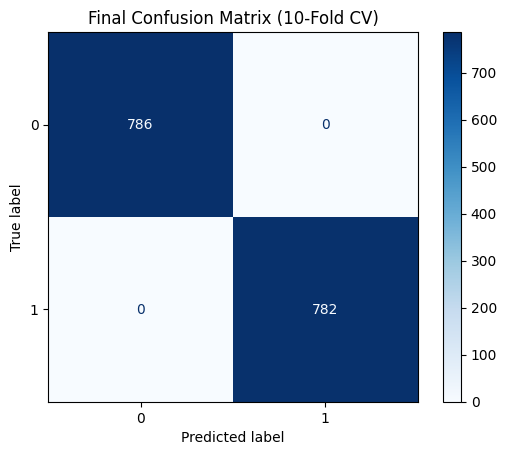

Final Classification Report (10-Fold CV):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       786
           1     1.0000    1.0000    1.0000       782

    accuracy                         1.0000      1568
   macro avg     1.0000    1.0000    1.0000      1568
weighted avg     1.0000    1.0000    1.0000      1568



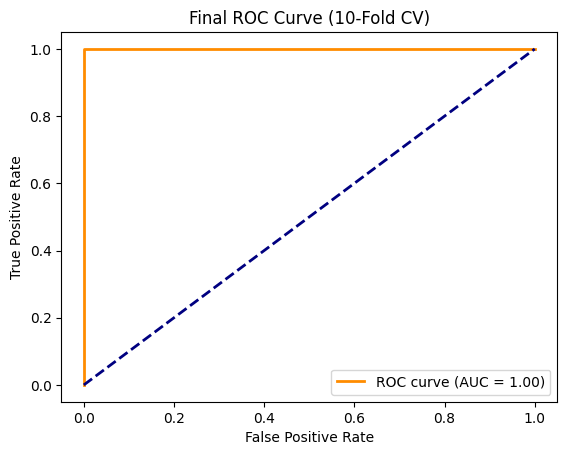

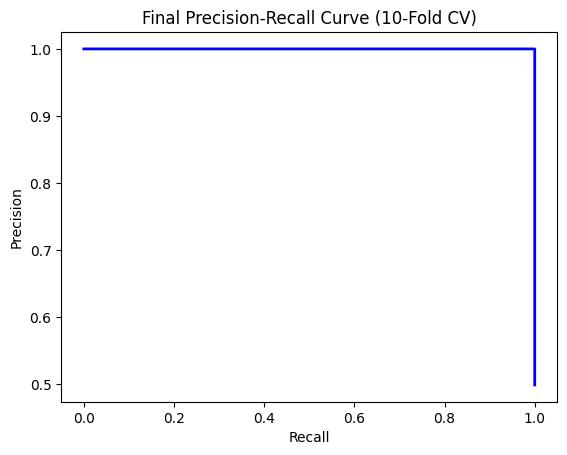

In [10]:
# Initialize lists for storing fold-wise metrics
all_y_true = []
all_y_pred = []
all_val_probs = []

# Loop through folds to aggregate predictions
for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    # Build validation graph
    similarity_matrix_val = cosine_similarity(X_val)
    val_edge_index = torch.tensor(np.array(np.where(similarity_matrix_val > 0.85)), dtype=torch.long)
    node_features_val = torch.tensor(X_val, dtype=torch.float)
    labels_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
    val_data = Data(x=node_features_val, edge_index=val_edge_index, y=labels_val)

    # Validate the trained model for this fold
    model.eval()
    with torch.no_grad():
        val_output = model(val_data.x, val_data.edge_index)
        val_predictions = val_output.argmax(dim=1).cpu().numpy()
        val_probs = val_output.softmax(dim=1)[:, 1].cpu().numpy()

    # Store fold results
    all_y_true.extend(y_val)
    all_y_pred.extend(val_predictions)
    all_val_probs.extend(val_probs)

# Calculate final metrics
final_cm = confusion_matrix(all_y_true, all_y_pred)
final_report = classification_report(all_y_true, all_y_pred, digits=4)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=final_cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix (10-Fold CV)")
plt.show()

# Print classification report
print("Final Classification Report (10-Fold CV):")
print(final_report)

# ROC Curve (Aggregated)
fpr, tpr, _ = roc_curve(all_y_true, all_val_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve (10-Fold CV)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve (Aggregated)
precision, recall, _ = precision_recall_curve(all_y_true, all_val_probs)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Precision-Recall Curve (10-Fold CV)")
plt.show()


PermutationExplainer explainer: 1569it [1:32:50,  3.56s/it]                          


TypeError: only integer scalar arrays can be converted to a scalar index

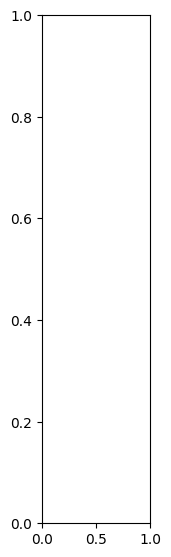

In [15]:
import shap
# Wrapper function for the GraphSAGE model
def model_predict(data):
    """
    Predict function for SHAP that converts tabular inputs to the format expected by the model.
    """
    node_features = torch.tensor(data, dtype=torch.float)
    edge_index = torch.tensor(
        np.array(np.where(cosine_similarity(data) > 0.85)), dtype=torch.long
    )
    with torch.no_grad():
        logits = model(node_features, edge_index)
        probs = torch.softmax(logits, dim=1).numpy()
    return probs

# Initialize SHAP explainer with the wrapper function
explainer = shap.Explainer(model_predict, X_resampled)

# Calculate SHAP values
shap_values = explainer(X_resampled)


In [17]:
print(type(shap_values))
print(shap_values.values.shape)  # Should match the number of rows and columns in X_resampled
print(len(X.columns))


<class 'shap._explanation.Explanation'>
(1568, 38, 2)
38


In [18]:
# Select SHAP values for the positive class (class 1)
shap_values_class1 = shap_values.values[:, :, 1]


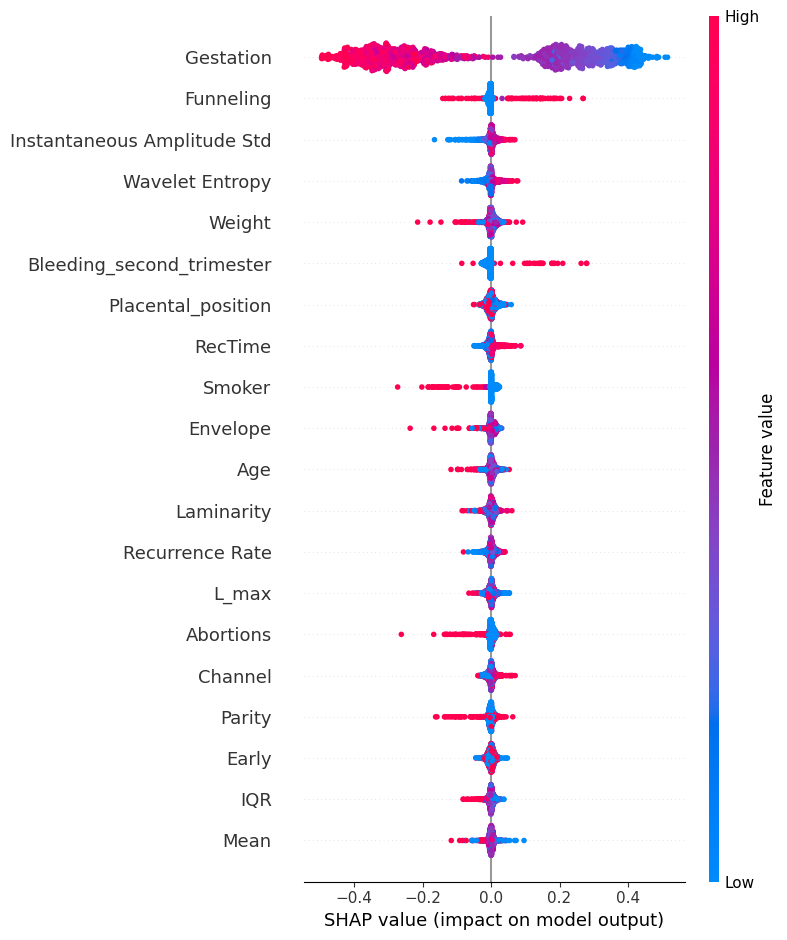

In [19]:
# Convert X_resampled to a DataFrame
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)

# Generate global feature importance plot
shap.summary_plot(shap_values_class1, X_resampled_df, feature_names=X.columns.tolist())


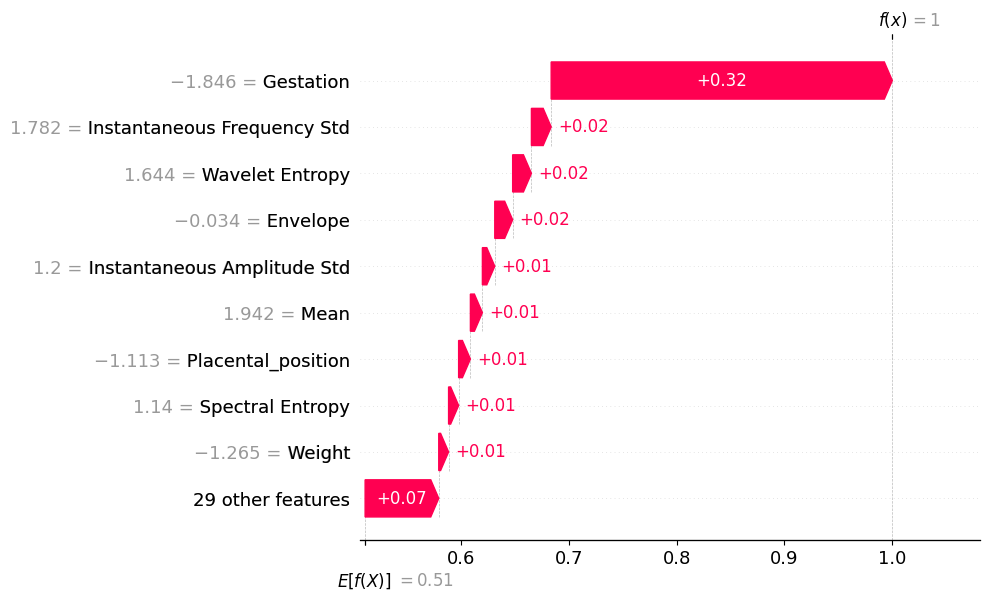

In [20]:
instance_index = 0  # Adjust the index to the sample of interest

# Generate waterfall plot for the selected instance
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_class1[instance_index],
        base_values=shap_values.base_values[instance_index, 1],  # Base value for class 1
        data=X_resampled_df.iloc[instance_index].values,
        feature_names=X.columns.tolist()
    )
)


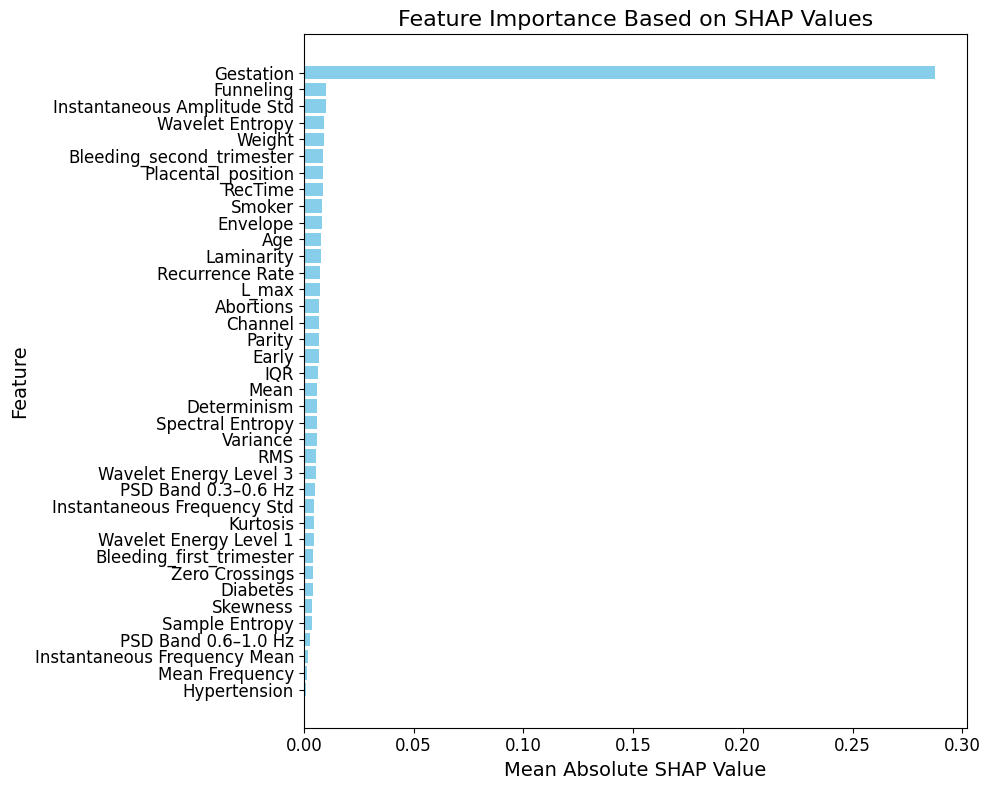

In [21]:
import matplotlib.pyplot as plt

# Calculate mean absolute SHAP values for each feature
mean_abs_shap_values = np.mean(np.abs(shap_values_class1), axis=0)

# Create a DataFrame for better handling and sorting
feature_importance = pd.DataFrame({
    "Feature": X.columns.tolist(),
    "Importance": mean_abs_shap_values
}).sort_values(by="Importance", ascending=False)

# Plot the bar chart
plt.figure(figsize=(10, 8))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="skyblue")
plt.xlabel("Mean Absolute SHAP Value", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance Based on SHAP Values", fontsize=16)
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [23]:
# Extract SHAP values for each class
shap_values_class0 = shap_values.values[:, :, 0]  # For class 0
shap_values_class1 = shap_values.values[:, :, 1]  # For class 1


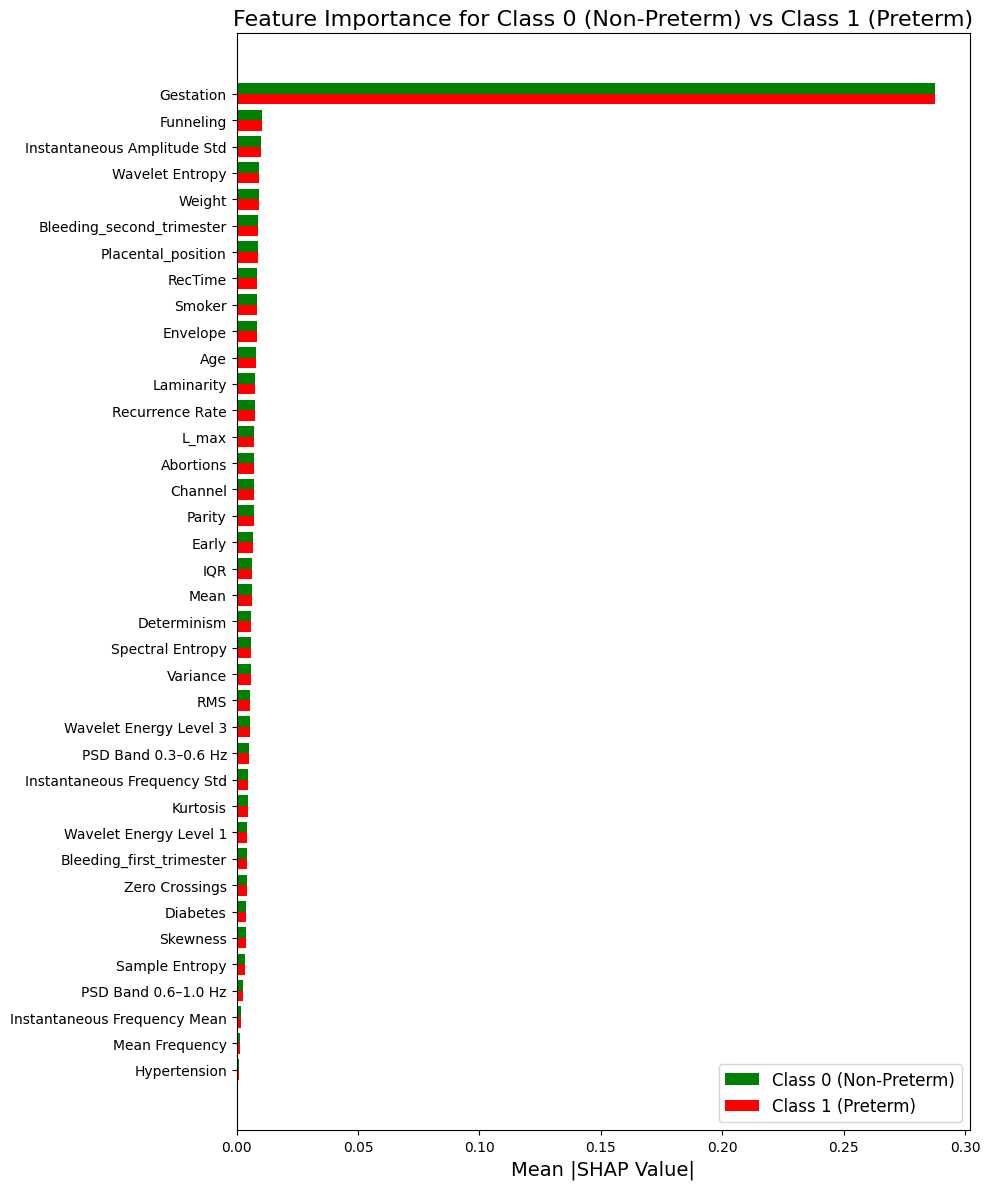

In [25]:
# Compute mean absolute SHAP values for both classes
mean_shap_class0 = np.abs(shap_values_class0).mean(axis=0)  # Class 0 (non-preterm)
mean_shap_class1 = np.abs(shap_values_class1).mean(axis=0)  # Class 1 (preterm)

# Sort features by importance for Class 1 (preterm)
sorted_indices = np.argsort(mean_shap_class1)[::-1]
sorted_features = X.columns[sorted_indices]
mean_shap_class0_sorted = mean_shap_class0[sorted_indices]
mean_shap_class1_sorted = mean_shap_class1[sorted_indices]

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot class 0 (non-preterm)
ax.barh(
    y=np.arange(len(sorted_features)) - 0.2,  # Offset for horizontal layout
    width=mean_shap_class0_sorted,
    height=0.4,
    color="green",
    label="Class 0 (Non-Preterm)"
)

# Plot class 1 (preterm)
ax.barh(
    y=np.arange(len(sorted_features)) + 0.2,  # Offset for horizontal layout
    width=mean_shap_class1_sorted,
    height=0.4,
    color="red",
    label="Class 1 (Preterm)"
)

# Add labels and title
ax.set_yticks(np.arange(len(sorted_features)))
ax.set_yticklabels(sorted_features, fontsize=10)
ax.set_xlabel("Mean |SHAP Value|", fontsize=14)
ax.set_title("Feature Importance for Class 0 (Non-Preterm) vs Class 1 (Preterm)", fontsize=16)
ax.legend(fontsize=12, loc="lower right")

plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.tight_layout()
plt.show()
